# Temporal tracking

`TemporalHypergrid` wraps any hypergrid and adds two capabilities:

1. **Exponential decay** — old counts are multiplied by `decay` before each update,
   so recent data carries more weight (like an exponential moving average).
2. **Snapshots** — a copy of the distribution is saved every `snapshot_interval`
   data points, allowing drift to be measured over time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypergrid import DenseHypergrid, TemporalHypergrid, compute_edges

## 1. Setup

In [2]:
rng = np.random.default_rng(0)

# Pre-compute edges that cover both the initial and drifted distributions
all_data = np.vstack([
    rng.standard_normal((3000, 2)),
    rng.standard_normal((3000, 2)) + 2.0,
])
edges = compute_edges(all_data)

base = DenseHypergrid(edges)
tgrid = TemporalHypergrid(base, decay=0.98, snapshot_interval=500)

## 2. Streaming updates with a drifting distribution

In [3]:
n_batches = 20
batch_size = 500
rng2 = np.random.default_rng(1)

for i in range(n_batches):
    # Distribution shifts linearly from 0 to +2 over the stream
    shift = i * (2.0 / n_batches)
    batch = rng2.standard_normal((batch_size, 2)) + shift
    tgrid.update(batch)

print(f"Snapshots saved: {len(tgrid.snapshots)}")

Snapshots saved: 20


## 3. Evolution — divergence between consecutive snapshots

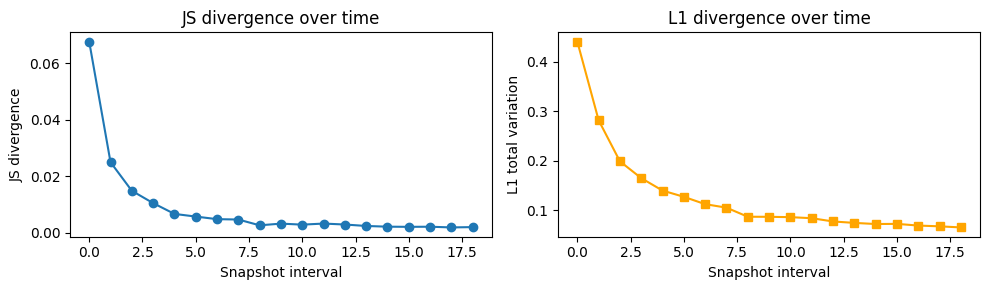

In [4]:
js_divergences = tgrid.evolution(method="js")
l1_divergences = tgrid.evolution(method="l1")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(js_divergences, marker="o")
axes[0].set_title("JS divergence over time")
axes[0].set_xlabel("Snapshot interval")
axes[0].set_ylabel("JS divergence")

axes[1].plot(l1_divergences, marker="s", color="orange")
axes[1].set_title("L1 divergence over time")
axes[1].set_xlabel("Snapshot interval")
axes[1].set_ylabel("L1 total variation")

plt.tight_layout()
plt.show()

## 4. Effect of decay — comparing decayed vs non-decayed

With decay (0.9) — recent shift should dominate:


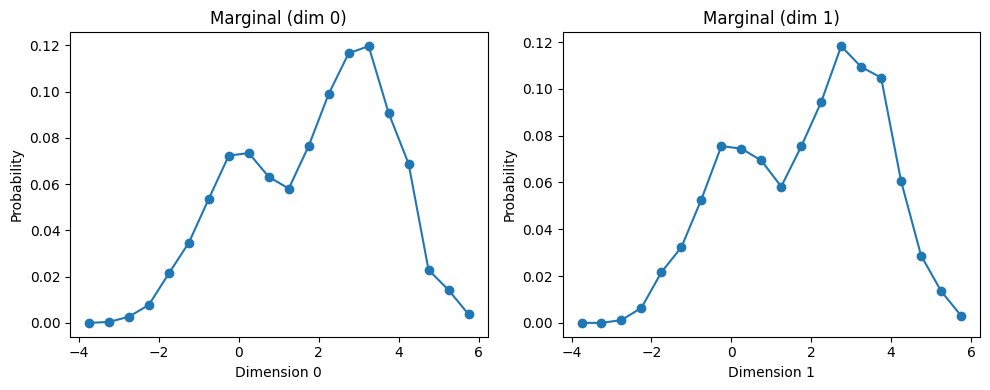

Without decay — both phases equally weighted:


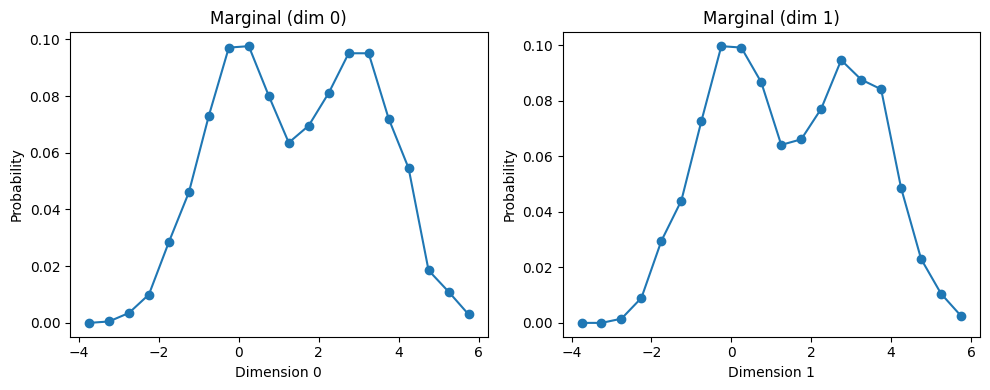

In [5]:
# Burst of data from one distribution, then switch to another
edges_simple = [np.linspace(-4, 6, 21), np.linspace(-4, 6, 21)]
rng3 = np.random.default_rng(2)

g_decay = TemporalHypergrid(DenseHypergrid(edges_simple), decay=0.9, snapshot_interval=10000)
g_nodecay = TemporalHypergrid(DenseHypergrid(edges_simple), decay=None, snapshot_interval=10000)

# Phase 1: distribution centred at 0
for _ in range(5):
    b = rng3.standard_normal((200, 2))
    g_decay.update(b)
    g_nodecay.update(b)

# Phase 2: distribution now centred at 3
for _ in range(5):
    b = rng3.standard_normal((200, 2)) + 3.0
    g_decay.update(b)
    g_nodecay.update(b)

print("With decay (0.9) — recent shift should dominate:")
g_decay.grid.plot_all_marginals()

print("Without decay — both phases equally weighted:")
g_nodecay.grid.plot_all_marginals()

## 5. plot_evolution convenience method

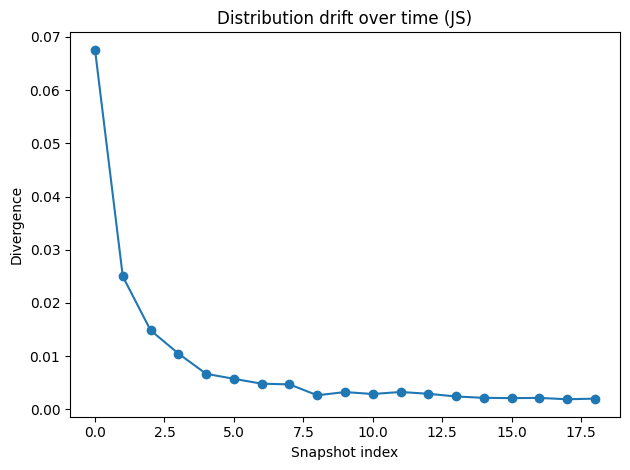

In [6]:
tgrid.plot_evolution(method="js")

## 6. Temporal UMAP (requires umap-learn)

Projects samples from each snapshot into 2D space, coloured by snapshot index.

c:\Users\cleme\PROJECTS\HYPERGRID\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


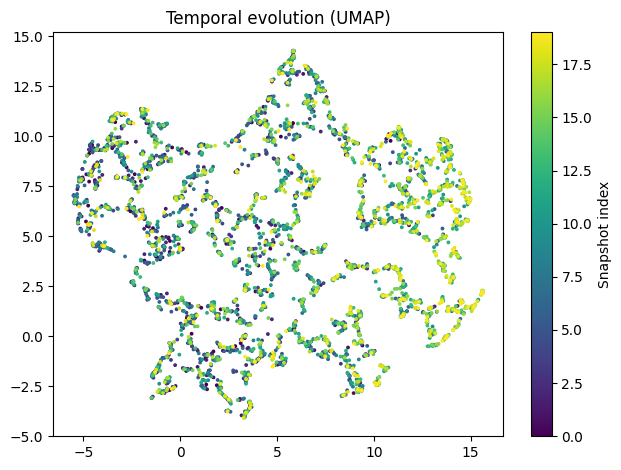

In [7]:
# Requires: pip install "hypergrid[umap]"
tgrid.plot_temporal_umap(n_per_snapshot=200)